# Chapter 2 design demo
Projection-inspired and LP-inspired finite-dimensional surrogates on a toy static system.

## 1) Environment/bootstrap
This code cell makes the notebook runnable from different working directories by searching for `src/mpmgame` and adding `src/` to `sys.path`.

**Why this block is here:** it avoids `ModuleNotFoundError` if the package is not installed in the active kernel.

**Expected outcome:** printed module path for `mpmgame`; no modeling claims are made in this step.

In [1]:
from pathlib import Path
import sys
cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    src_dir = candidate / 'src'
    if (src_dir / 'mpmgame').exists():
        sys.path.insert(0, str(src_dir))
        break
import numpy as np
import pandas as pd
import mpmgame as mpm
print('using', mpm.__file__)


using C:\Users\perry\Documents\VSCode\masked-perturbation-model\src\mpmgame\__init__.py


## 2) Define a toy contract/interconnection system and baseline vulnerability
This block defines a small static 3-subsystem example (`G`, `alpha`), initializes `Q=0`, builds the chapter-2 system object, and computes baseline single-link measured vulnerability under access model `w2`.

**Where it fits:** establishes the reference point for both surrogate design methods.

**What it demonstrates:** the baseline attack-map magnitude before any design changes to `Q`.

**Expected behavior:** returns a finite scalar `v0`; this is the value both methods try to reduce (numerically, via surrogates).

In [2]:
G = np.diag([0.75, 0.6, 0.55])
alpha = np.array([[0, 0.25, 0], [0.2, 0, 0.15], [0, 0.2, 0]])
system = mpm.build_contract_system(G, alpha, label='design_base')
Q_init = np.zeros((3,3))
pbar0 = mpm.access_matrix(system, Q_init, 'w2')
v0 = mpm.vulnerability_single_link(system, Q_init, pbar0).value
v0


1.0334849111202977

## 3) Run projection-inspired surrogate design and inspect convergence
This cell runs `projection_design(...)` for several iterations, then constructs an iteration table containing:
- surrogate objective,
- true measured vulnerability at each iterate,
- step acceptance flag.

It also plots convergence with `plot_projection_convergence`.

**Where it fits:** first design pathway (regularized least-squares surrogate).

**What it demonstrates:** whether the surrogate objective and measured vulnerability trend downward on this toy case.

**How to read the figure:**
- left panel: surrogate objective vs iteration (method-internal target),
- right panel: measured vulnerability vs iteration (external validation metric).

**Expected behavior:** often decreases early, but because this is a surrogate method, monotonic decrease of true vulnerability is not guaranteed in all systems.

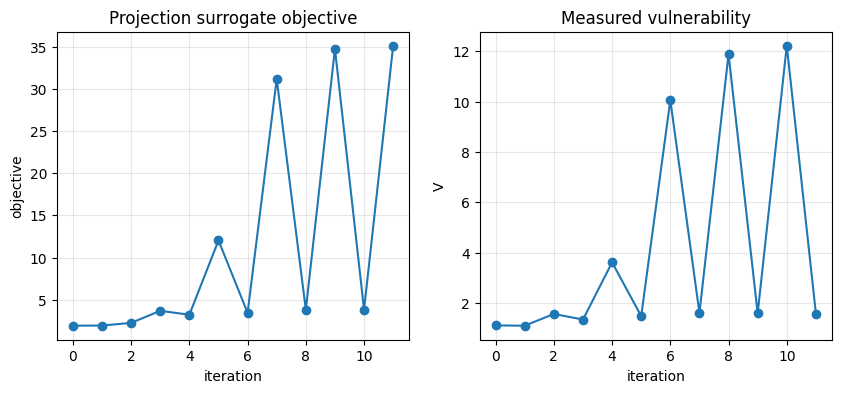

In [3]:
proj = mpm.projection_design(system, Q0=Q_init, max_iter=12, access_model='w2', threat_model='single_link', damping=0.6)
iters = pd.DataFrame([{
    'iter': i,
    'surrogate_obj': s.surrogate_obj,
    'measured_vulnerability': s.measured_vulnerability,
    'accepted': s.accepted
} for i, s in enumerate(proj.iterations)])
iters
_ = mpm.plot_projection_convergence(iters)


## 4) Run LP-inspired relaxation design
This block runs `lp_relaxation_design(...)`, which uses a finite-dimensional linearized surrogate and `linprog`.

**Where it fits:** second design pathway (LP-style relaxation).

**What it demonstrates:** feasibility/status of the LP surrogate and resulting surrogate-vs-true values.

**Expected behavior:**
- `lp.success` indicates solver feasibility/success,
- `lp.surrogate_value` is the LP target,
- `lp.true_vulnerability` is the post-design measured metric used for honest comparison.

Differences between surrogate and true values are expected and are part of the point of this demo.

In [4]:
lp = mpm.lp_relaxation_design(system, Q_linearization=Q_init, access_model='w2', threat_model='single_link', g_hat=0.25)
lp.success, lp.surrogate_value, lp.true_vulnerability


(True, 0.9792269532864821, 1.1000872720591615)

## 5) Compare baseline vs projection vs LP on true measured vulnerability
This final block creates a bar chart comparing *true measured vulnerability* for:
1. baseline `Q=0`,
2. final projection iterate,
3. LP-designed `Q`.

**Where it fits:** consolidated summary view.

**What it demonstrates:** practical effect size of each surrogate design on the actual measurement criterion.

**How to interpret:** lower bars are better for this threat model. If a surrogate underperforms baseline, that is still informative and indicates relaxation mismatch or local issues, not a code error by itself.

Note: projection and LP steps are finite-dimensional surrogates/relaxations.


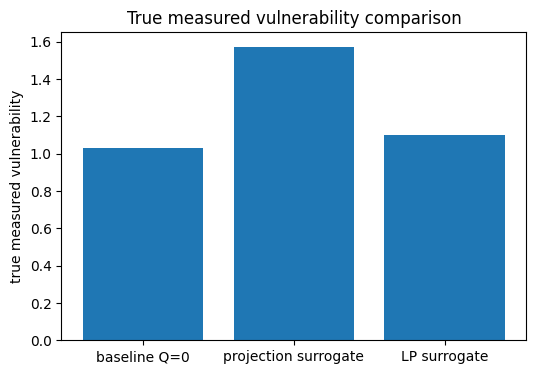

In [5]:
vals = [v0, proj.iterations[-1].measured_vulnerability if proj.iterations else v0, lp.true_vulnerability]
labels = ['baseline Q=0', 'projection surrogate', 'LP surrogate']
_ = mpm.plot_design_comparison(labels, vals, title='True measured vulnerability comparison')
print('Note: projection and LP steps are finite-dimensional surrogates/relaxations.')


## Takeaways and honesty notes
- This notebook is a **numerical demonstration** on a small static toy system.
- Projection and LP methods here are **finite-dimensional surrogates/relaxations** inspired by chapter-2 sketches.
- Results should be interpreted as sanity checks and empirical behavior, not theorem proofs.